## Imports & Installs

In [ ]:
#Installs and Imports

!pip install yfinance --upgrade --quiet

import yfinance as yf
import pandas as pd
import seaborn as sns
import numpy as np
import os, glob
import matplotlib.pyplot as plt
import pytz
import matplotlib.lines as mlines
import re


from scipy.stats import norm
from math import erf, sqrt, log, exp
from scipy.optimize import brentq, least_squares
from datetime import date
from datetime import datetime
from google.colab import files
from pathlib import Path

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.1/127.1 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 100.4 MB/s eta 0:00:00


## Data (unfiltered)

In [ ]:
# Tickers

# BAC = Bank of America, JPM = JP Morgan Chase and Company, WFC = Wells Fargo and Company, MRK = Merck and Company,
# PFE = Pfizer, UNH = United Health Group Incorporated, AAPL = Apple Inc, MSFT = Microsoft Corporation, NVDA = NVIDIA Corporation

tickers = ['BAC', 'JPM', 'WFC', 'MRK', 'PFE', 'UNH', 'AAPL', 'MSFT', 'NVDA']

In [ ]:
#Reads your uploaded csv file of interest

DATA_DIR = "."

csv_files = sorted([
    f for f in os.listdir(DATA_DIR)
    if re.match(r"calls-\d{4}-\d{2}-\d{2}\.csv$", f)
])

print(f"Found {len(csv_files)} files:")
print(csv_files)

dfs = [pd.read_csv(os.path.join(DATA_DIR, f)) for f in csv_files]
combined_calls_df = pd.concat(dfs, ignore_index=True)

Found 1 files:
['calls-2025-08-29.csv']


In [ ]:
combined_calls_df.columns

Index(['contractSymbol', 'lastTradeDate', 'strike', 'lastPrice', 'bid', 'ask',
       'change', 'percentChange', 'volume', 'openInterest',
       'impliedVolatility', 'inTheMoney', 'contractSize', 'currency', 'symbol',
       'stockPrice', 'empirical_option_Price', 'moneyness', 'trading_day',
       'time_to_expiry', 'risk_free_rate', 'dividend_yield', 'BSM_price',
       'pricing_error', 'relative_error_%', 'BSM_price_div',
       'pricing_error_div', 'relative_error_div_%'],
      dtype='object')

In [ ]:
combined_calls_df[['contractSymbol','lastPrice','bid', 'ask','symbol','stockPrice',
       'empirical_option_Price','BSM_price','BSM_price_div','pricing_error','pricing_error_div','trading_day', 'time_to_expiry']]

,contractSymbol,lastPrice,bid,ask,symbol,stockPrice,empirical_option_Price,BSM_price,BSM_price_div,pricing_error,pricing_error_div,trading_day,time_to_expiry
0,BAC250919C00020000,30.40,30.70,30.80,BAC,50.740002,30.750,30.815980,30.749519,0.065980,-0.000481,2025-08-29,0.059524
1,BAC250919C00022000,12.35,19.85,20.00,BAC,50.740002,19.925,28.797676,28.730973,8.872676,8.805973,2025-08-29,0.059524
2,BAC250919C00023000,12.15,18.50,18.60,BAC,50.740002,18.550,27.800298,27.733594,9.250298,9.183594,2025-08-29,0.059524
3,BAC250919C00024000,22.50,0.00,0.00,BAC,50.740002,0.000,26.802919,26.736216,26.802919,26.736216,2025-08-29,0.059524
4,BAC250919C00025000,24.55,25.65,25.80,BAC,50.740002,25.725,25.915623,25.849933,0.190623,0.124933,2025-08-29,0.059524
...,...,...,...,...,...,...,...,...,...,...,...,...,...
739,NVDA250919C02280000,65.79,63.65,65.85,NVDA,174.179993,64.750,80.564071,80.562808,15.814071,15.812808,2025-08-29,0.059524
740,NVDA250919C02300000,64.47,61.70,64.10,NVDA,174.179993,62.900,78.621621,78.620380,15.721621,15.720380,2025-08-29,0.059524
741,NVDA250919C02350000,64.25,58.30,60.30,NVDA,174.179993,59.300,74.818051,74.816852,15.518051,15.516852,2025-08-29,0.059524
742,NVDA250919C02400000,55.50,54.65,56.90,NVDA,174.179993,55.775,71.052976,71.051820,15.277976,15.276820,2025-08-29,0.059524


In [ ]:
# Checking number of call options per tickers
total=[]
for symbol in tickers:
    calls = combined_calls_df.loc[combined_calls_df['symbol'] == symbol]  # <-- boolean filter
    print(f"{symbol}: num_calls = {len(calls)}")
    total.append(len(calls))
print('----------------------')
print(f"Total call options after filtering = {np.array(total).sum()}")

BAC: num_calls = 51
JPM: num_calls = 63
WFC: num_calls = 48
MRK: num_calls = 46
PFE: num_calls = 36
UNH: num_calls = 92
AAPL: num_calls = 80
MSFT: num_calls = 96
NVDA: num_calls = 232
----------------------
Total call options after filtering = 744


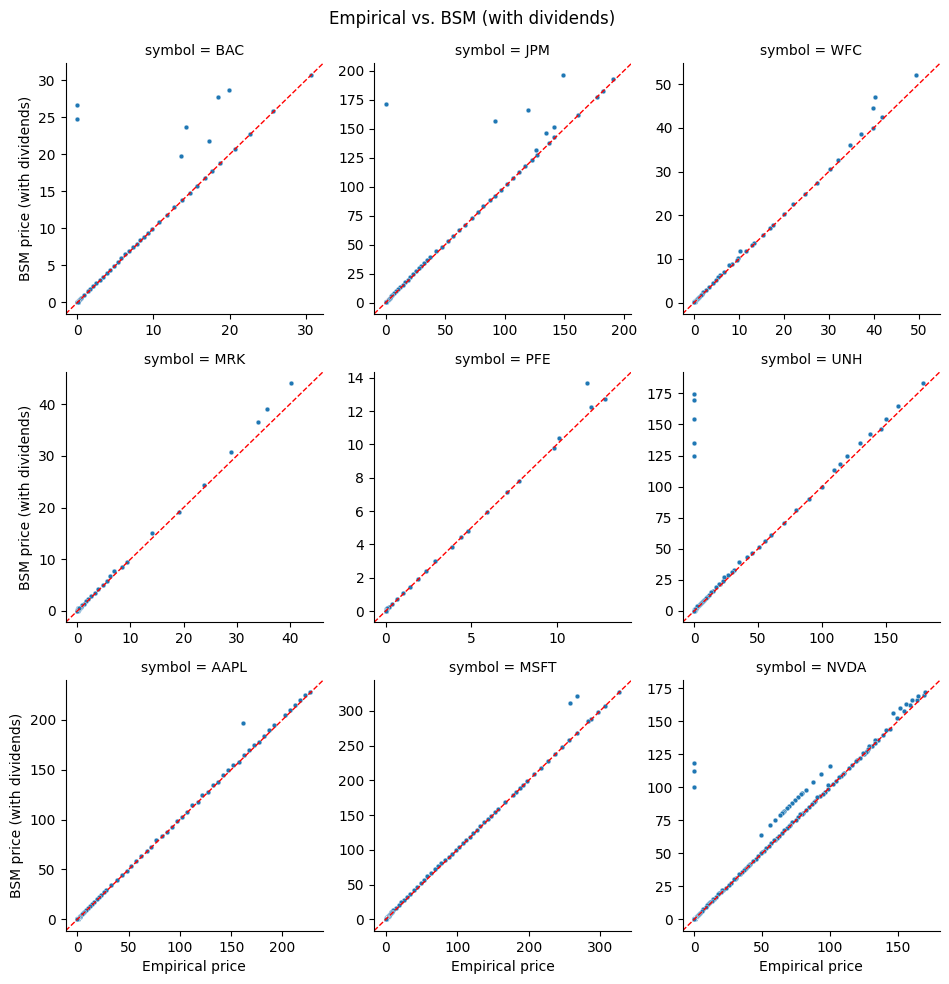

In [ ]:
df_plot = combined_calls_df.dropna(
    subset=["empirical_option_Price", "BSM_price_div", "symbol"]
).copy()

# Facet scatter plots by ticker
g = sns.FacetGrid(df_plot, col="symbol", col_wrap=3, sharex=False, sharey=False, height=3.2)
g.map_dataframe(sns.scatterplot, x="empirical_option_Price", y="BSM_price_div", s=12)

# Add 45° line to each facet
for ax in g.axes.flat:
    if ax is None:
        continue
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    lo = min(xlim[0], ylim[0])
    hi = max(xlim[1], ylim[1])
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

g.set_axis_labels("Empirical price", "BSM price (with dividends)")
g.fig.suptitle("Empirical vs. BSM (with dividends) ", y=1.02)
plt.show()

## Data (filtered)

In [ ]:
# Removing deep ITM rows which have bid = ask = 0, which makes empirical_price=0 so creating not desired “errors”.

df_flt = combined_calls_df.copy()

mask_zero_quotes = (
    (pd.to_numeric(df_flt["bid"], errors="coerce") == 0) &
    (pd.to_numeric(df_flt["ask"], errors="coerce") == 0)
)

df_flt= df_flt.loc[~mask_zero_quotes].copy()

# Also drop rows where empirical price is ~0
df_flt = df_flt[df_flt["empirical_option_Price"] > 0.01].copy()

# Keep only rows that have what we need
need_cols = ["symbol", "strike", "empirical_option_Price", "BSM_price_div"]
df_flt = df_flt.dropna(subset=need_cols)

# Ensure numeric where needed
for c in ["strike", "empirical_option_Price", "BSM_price_div"]:
    df_flt[c] = pd.to_numeric(df_flt[c], errors="coerce")

print(f"Kept {len(df_flt)} rows (from {len(combined_calls_df)}).")

Kept 621 rows (from 744).


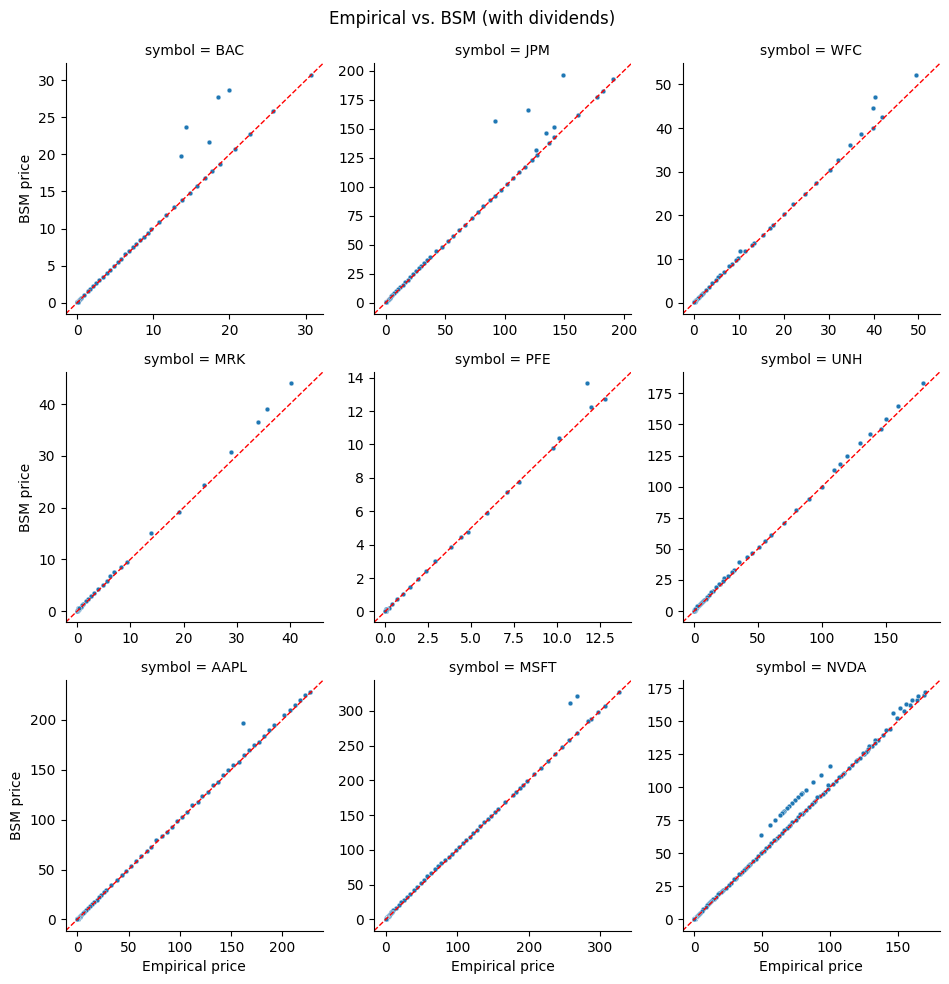

In [ ]:
# Facet scatter plots by ticker
g = sns.FacetGrid(df_flt, col="symbol", col_wrap=3, sharex=False, sharey=False, height=3.2)
g.map_dataframe(sns.scatterplot, x="empirical_option_Price", y="BSM_price_div", s=12)

# Add 45° line to each facet
for ax in g.axes.flat:
    if ax is None:
        continue
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    lo = min(xlim[0], ylim[0])
    hi = max(xlim[1], ylim[1])
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

g.set_axis_labels("Empirical price", "BSM price")
g.fig.suptitle("Empirical vs. BSM (with dividends) ", y=1.02)
plt.show()

In [ ]:
# Checking number of call options per tickers after filtering
total=[]
for symbol in tickers:
    calls = df_flt.loc[df_flt['symbol'] == symbol]  # <-- boolean filter
    print(f"{symbol}: num_calls = {len(calls)}")
    total.append(len(calls))
print('----------------------')
print(f"Total call options after filtering = {np.array(total).sum()}")

BAC: num_calls = 49
JPM: num_calls = 61
WFC: num_calls = 44
MRK: num_calls = 44
PFE: num_calls = 30
UNH: num_calls = 81
AAPL: num_calls = 69
MSFT: num_calls = 88
NVDA: num_calls = 155
----------------------
Total call options after filtering = 621


In [ ]:
# Number of call options for all stocks considered

total=[]
for symbol in tickers:
    calls = combined_calls_df.loc[combined_calls_df['symbol'] == symbol]  # <-- boolean filter
    print(f"{symbol}: num_calls = {len(calls)}")
    total.append(len(calls))
print('----------------------')
print(f"Total call options = {np.array(total).sum()}")

BAC: num_calls = 51
JPM: num_calls = 63
WFC: num_calls = 48
MRK: num_calls = 46
PFE: num_calls = 36
UNH: num_calls = 92
AAPL: num_calls = 80
MSFT: num_calls = 96
NVDA: num_calls = 232
----------------------
Total call options = 744


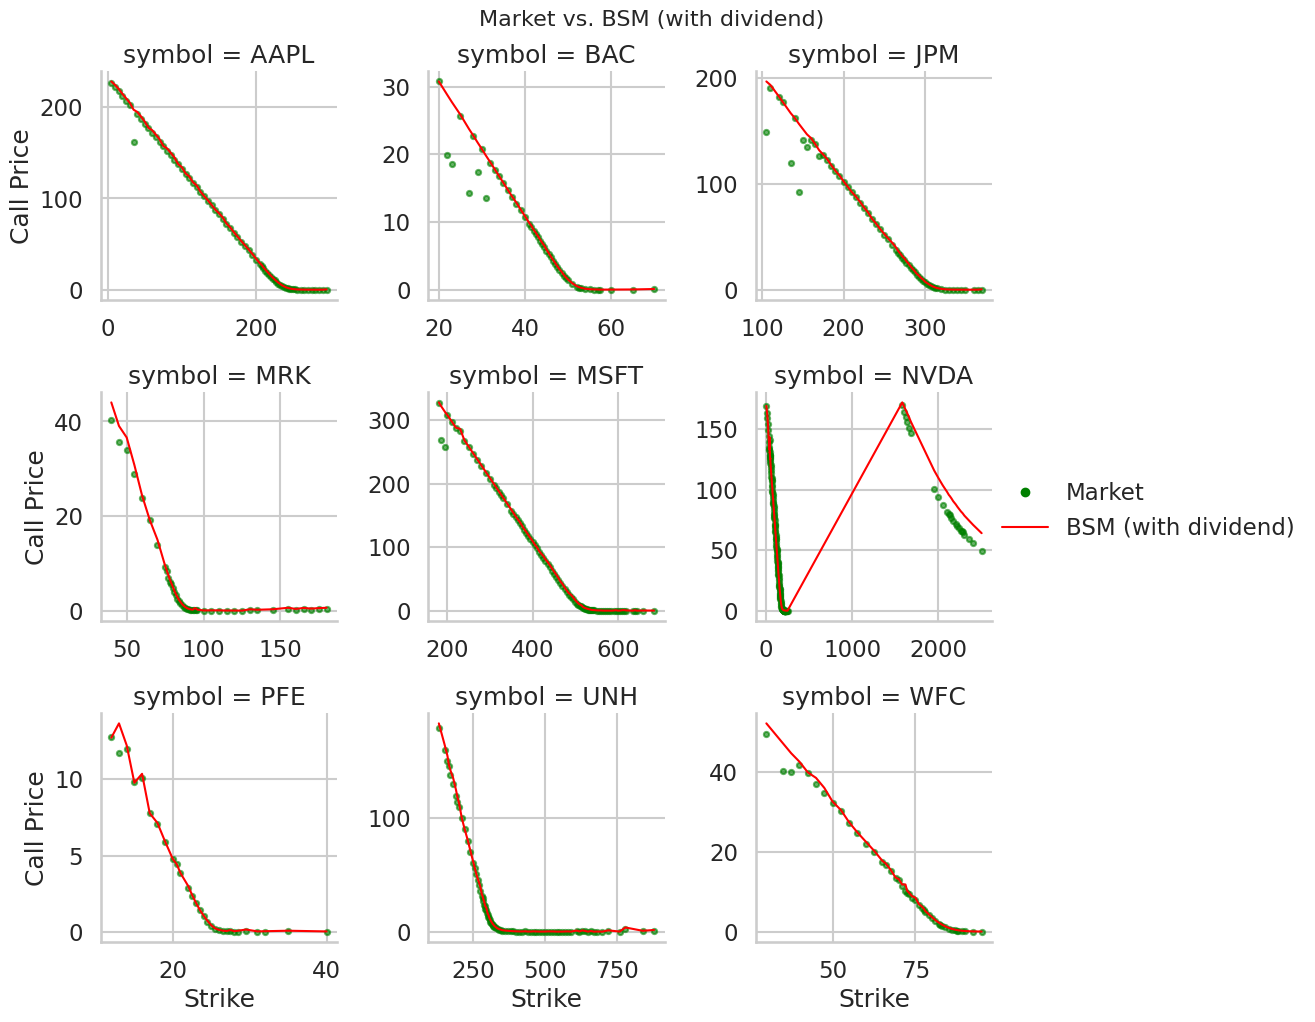

In [ ]:
def _facet_draw(data, color=None, **kws):
    data = data.sort_values("strike")
    # Market mid (empirical) as scatter
    plt.scatter(data["strike"], data["empirical_option_Price"], s=14, c="green", alpha=0.6)
    # BSM with dividend as a line
    plt.plot(data["strike"], data["BSM_price_div"], linewidth=1.5, c="red")

sns.set_style("whitegrid")
sns.set_context("talk")

g = sns.FacetGrid(
    df_flt.sort_values(["symbol","strike"]),
    col="symbol",
    col_wrap=3,            # 3x3 grid for your 9 tickers
    sharex=False,
    sharey=False,
    height=3.4
)
g.map_dataframe(_facet_draw)

# Legend for all facets
scatter_proxy = mlines.Line2D([], [], linestyle="none", marker="o", c="green", markersize=6, label="Market")
line_proxy    = mlines.Line2D([], [], linestyle="-",  linewidth=1.5, c="red", label="BSM (with dividend)")
g.add_legend(handles=[scatter_proxy, line_proxy], title="")

g.set_axis_labels("Strike", "Call Price")
g.fig.subplots_adjust(top=0.92)
g.fig.suptitle("Market vs. BSM (with dividend)", fontsize=16)

plt.show()

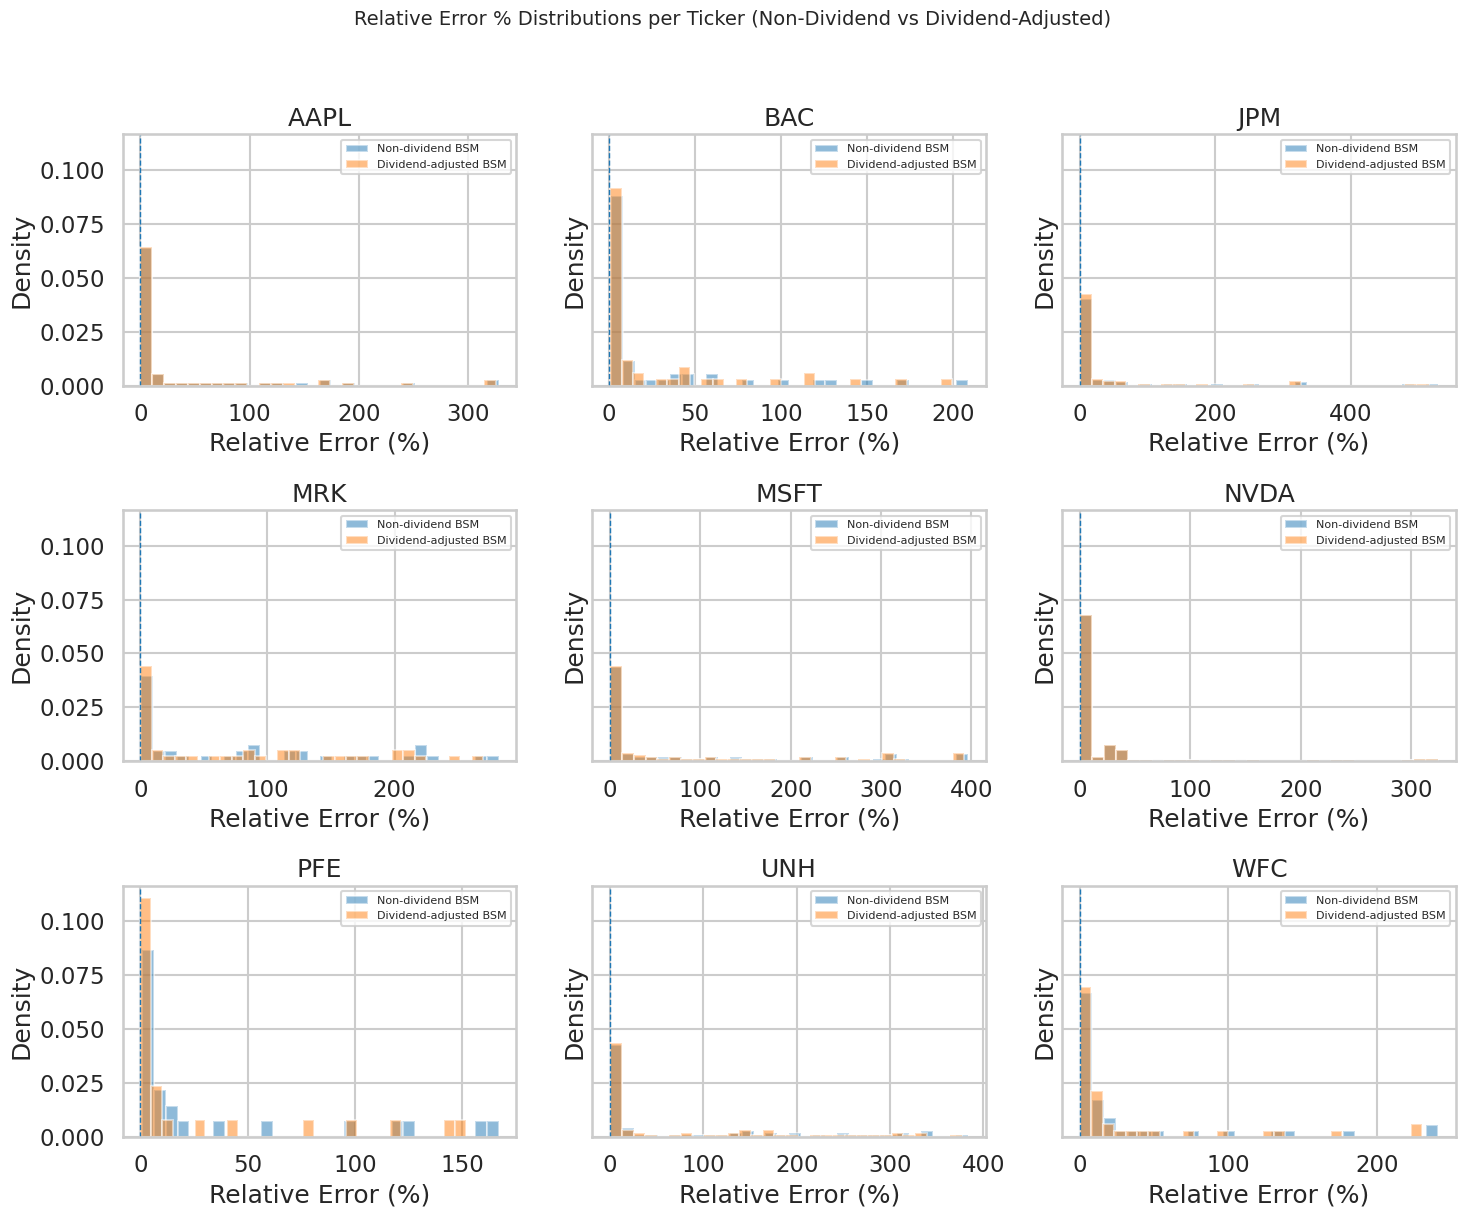

In [ ]:
df_plot = df_flt.dropna(subset=["symbol", "relative_error_%", "relative_error_div_%"]).copy()
df_plot["relative_error_%"] = pd.to_numeric(df_plot["relative_error_%"], errors="coerce")
df_plot["relative_error_div_%"] = pd.to_numeric(df_plot["relative_error_div_%"], errors="coerce")
df_plot = df_plot.dropna(subset=["relative_error_%", "relative_error_div_%"])

tickers = sorted(df_plot["symbol"].unique())
n = len(tickers)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows), sharex=False, sharey=True)
axes = axes.flatten()

for i, t in enumerate(tickers):
    dsub = df_plot[df_plot["symbol"] == t]
    axes[i].hist(dsub["relative_error_%"], bins=30, alpha=0.5, density=True, label="Non-dividend BSM")
    axes[i].hist(dsub["relative_error_div_%"], bins=30, alpha=0.5, density=True, label="Dividend-adjusted BSM")
    axes[i].axvline(0, linestyle="--", linewidth=1)
    axes[i].set_title(f"{t}")
    axes[i].set_xlabel("Relative Error (%)")
    axes[i].set_ylabel("Density")
    axes[i].legend(fontsize=8)

# Remove empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Relative Error % Distributions per Ticker (Non-Dividend vs Dividend-Adjusted)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

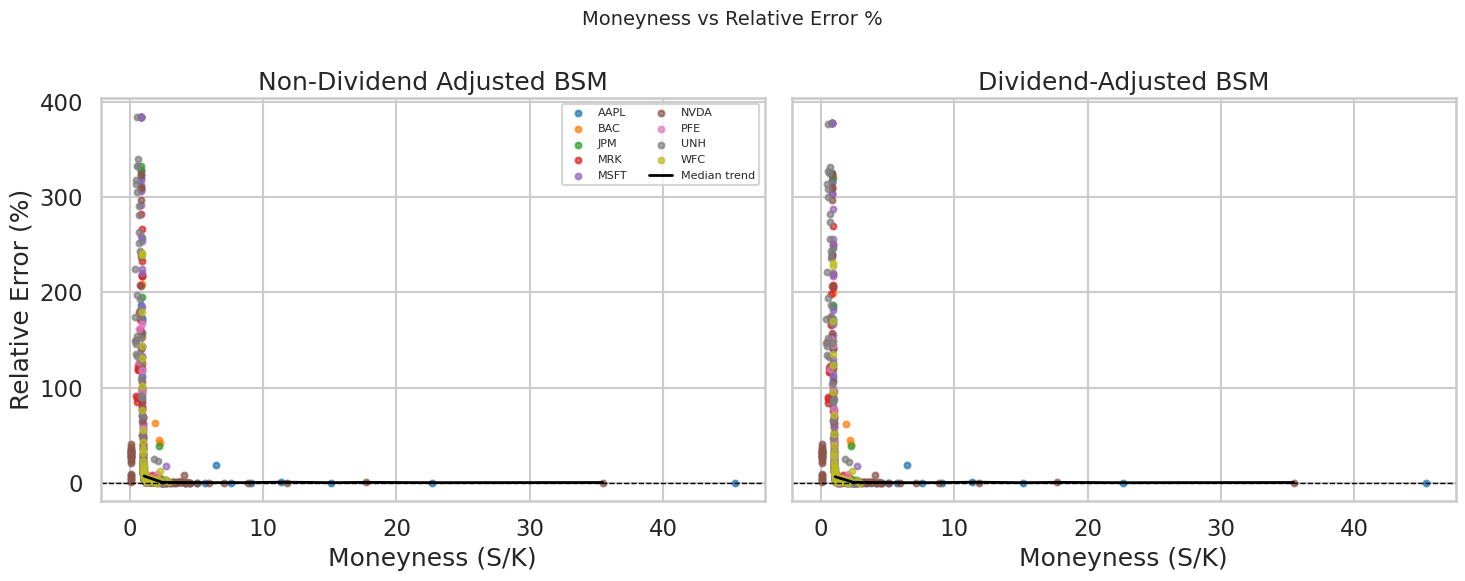

In [ ]:
df_plot = df_flt.dropna(subset=["symbol","moneyness","relative_error_%","relative_error_div_%"]).copy()
for c in ["moneyness","relative_error_%","relative_error_div_%"]:
    df_plot[c] = pd.to_numeric(df_plot[c], errors="coerce")
df_plot = df_plot.dropna(subset=["moneyness","relative_error_%","relative_error_div_%"])

# Clip extreme errors (top 1%) for readability
cap_plain = df_plot["relative_error_%"].quantile(0.99)
cap_div   = df_plot["relative_error_div_%"].quantile(0.99)
df_plot["rel_err_plain_clip"] = np.minimum(df_plot["relative_error_%"], cap_plain)
df_plot["rel_err_div_clip"]   = np.minimum(df_plot["relative_error_div_%"], cap_div)

# Helper function for binned median trend
def binned_trend(x, y, bins=25):
    x, y = x.values, y.values
    order = np.argsort(x)
    x_sorted, y_sorted = x[order], y[order]
    edges = np.linspace(x_sorted.min(), x_sorted.max(), bins + 1)
    xm, ym = [], []
    for i in range(bins):
        m = (x_sorted >= edges[i]) & (x_sorted < edges[i+1])
        if m.any():
            xm.append(x_sorted[m].mean())
            ym.append(np.median(y_sorted[m]))
    return np.array(xm), np.array(ym)

# Get distinct colors for tickers
tickers = sorted(df_plot["symbol"].unique())
palette = sns.color_palette("tab10", n_colors=len(tickers))

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# --- Left: Non-dividend adjusted ---
for t, color in zip(tickers, palette):
    d = df_plot[df_plot["symbol"] == t]
    axes[0].scatter(d["moneyness"], d["rel_err_plain_clip"], s=18, alpha=0.7, label=t, color=color)
axes[0].axhline(0, linestyle="--", linewidth=1, color="black")
xm, ym = binned_trend(df_plot["moneyness"], df_plot["rel_err_plain_clip"])
axes[0].plot(xm, ym, linewidth=2, color="black", label="Median trend")
axes[0].set_title("Non-Dividend Adjusted BSM")
axes[0].set_xlabel("Moneyness (S/K)")
axes[0].set_ylabel("Relative Error (%)")
axes[0].legend(ncol=2, fontsize=8, frameon=True)

# --- Right: Dividend-adjusted ---
for t, color in zip(tickers, palette):
    d = df_plot[df_plot["symbol"] == t]
    axes[1].scatter(d["moneyness"], d["rel_err_div_clip"], s=18, alpha=0.7, label=t, color=color)
axes[1].axhline(0, linestyle="--", linewidth=1, color="black")
xm2, ym2 = binned_trend(df_plot["moneyness"], df_plot["rel_err_div_clip"])
axes[1].plot(xm2, ym2, linewidth=2, color="black", label="Median trend")
axes[1].set_title("Dividend-Adjusted BSM")
axes[1].set_xlabel("Moneyness (S/K)")

plt.suptitle("Moneyness vs Relative Error %", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

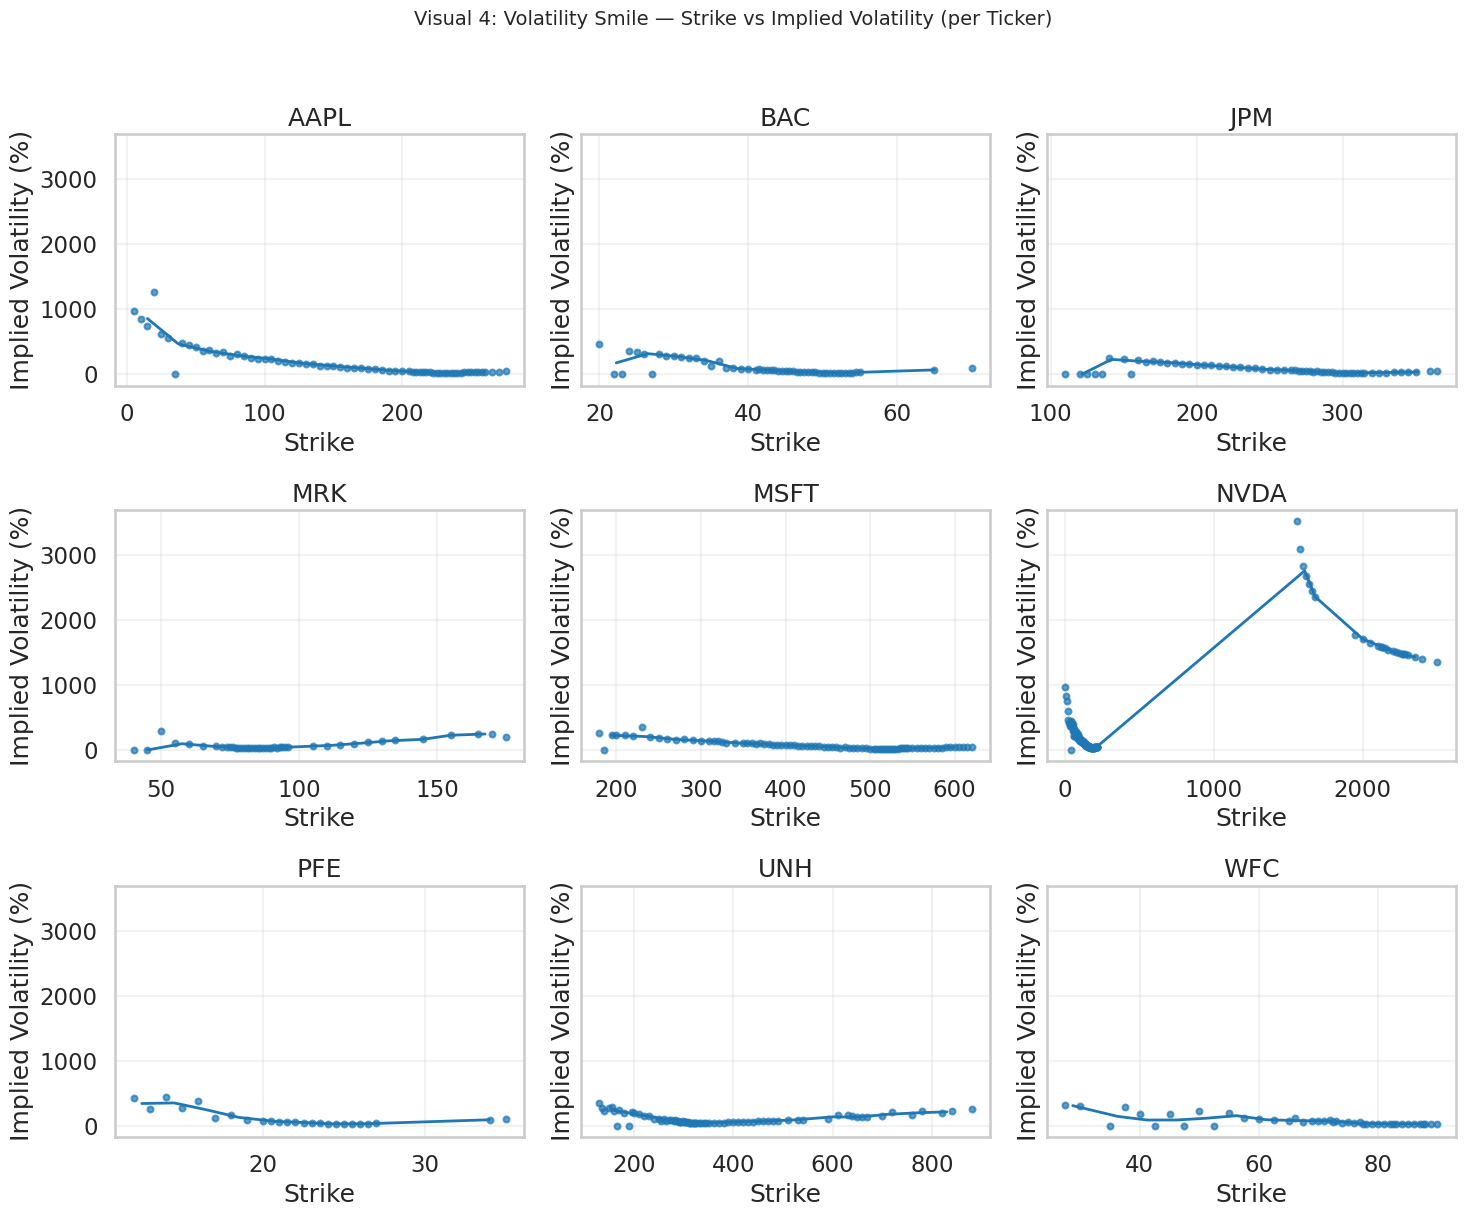

In [ ]:
# --- Visual 4: Volatility Smile (Strike vs Implied Volatility), per ticker ---
# median "smile" line.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use your filtered df_flt if present; otherwise fall back to the raw dataframe
try:
    df_iv = df_flt.copy()
except NameError:
    df_iv = combined_calls_df.copy() if "combined_calls_df" in globals() else calls_df.copy()

# Clean columns
need = ["symbol", "strike", "impliedVolatility"]
df_iv = df_iv.dropna(subset=need).copy()
df_iv["strike"] = pd.to_numeric(df_iv["strike"], errors="coerce")
df_iv["impliedVolatility"] = pd.to_numeric(df_iv["impliedVolatility"], errors="coerce")
df_iv = df_iv.dropna(subset=["strike", "impliedVolatility"])

# Convert to percent for readability
df_iv["iv_pct"] = df_iv["impliedVolatility"] * 100.0

tickers = sorted(df_iv["symbol"].unique())
n = len(tickers)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4*nrows), sharex=False, sharey=True)
axes = axes.flatten()

def binned_median(x, y, bins=12):
    x = x.values; y = y.values
    order = np.argsort(x)
    x = x[order]; y = y[order]
    edges = np.linspace(x.min(), x.max(), bins + 1)
    xc, yc = [], []
    for i in range(bins):
        m = (x >= edges[i]) & (x < edges[i+1])
        if m.any():
            xc.append(x[m].mean())
            yc.append(np.median(y[m]))
    return np.array(xc), np.array(yc)

for i, t in enumerate(tickers):
    d = df_iv[df_iv["symbol"] == t]
    ax = axes[i]
    ax.scatter(d["strike"], d["iv_pct"], s=18, alpha=0.7)
    xm, ym = binned_median(d["strike"], d["iv_pct"], bins=12)
    if len(xm) > 1:
        ax.plot(xm, ym, linewidth=2)
    ax.set_title(t)
    ax.set_xlabel("Strike")
    ax.set_ylabel("Implied Volatility (%)")
    ax.grid(alpha=0.25)

# Remove any unused subplots if tickers < grid slots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Visual 4: Volatility Smile — Strike vs Implied Volatility (per Ticker)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

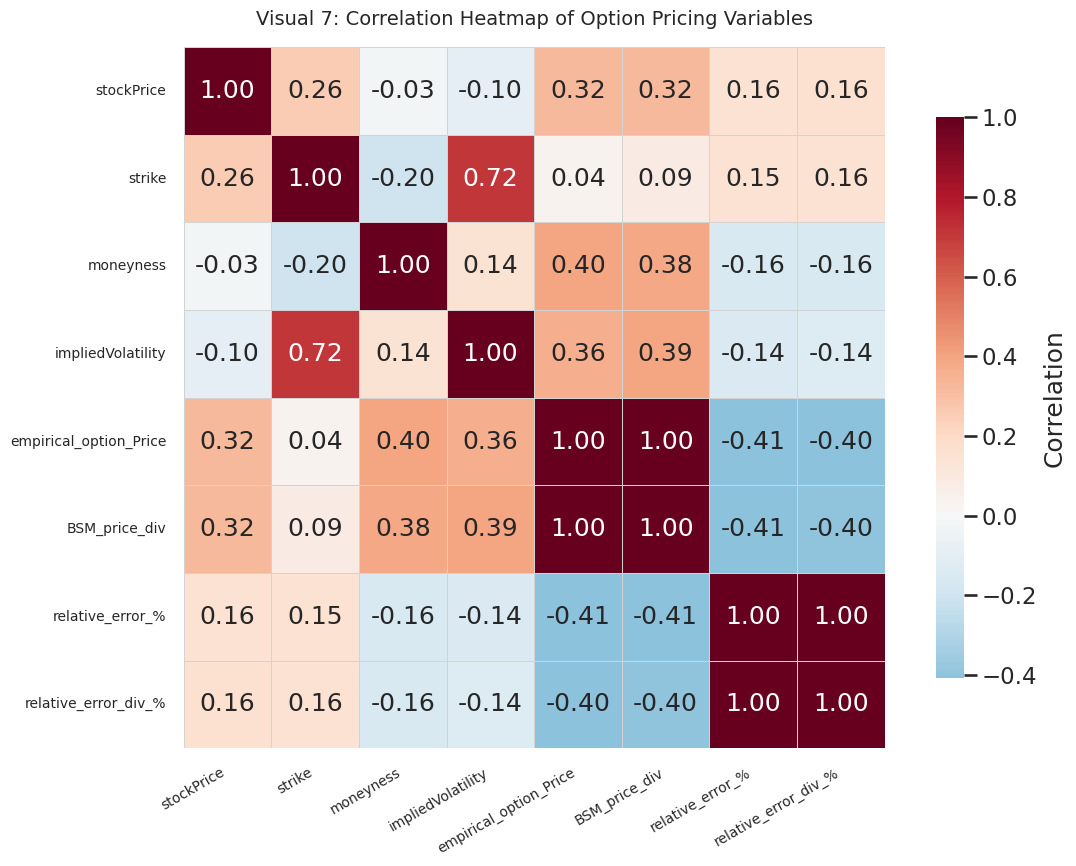

In [ ]:
# --- Visual 7: Prettier Correlation Heatmap ---

import seaborn as sns
import matplotlib.pyplot as plt

corr_vars = [
    "stockPrice", "strike", "moneyness",
    "impliedVolatility", "empirical_option_Price",
    "BSM_price_div", "relative_error_%", "relative_error_div_%"
]

df_corr = df_flt[corr_vars].copy()
df_corr = df_corr.apply(pd.to_numeric, errors="coerce").dropna()

# Correlation matrix
corr_matrix = df_corr.corr()

# Bigger figure, better color scheme, and annotations
plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f",
    cmap="RdBu_r", center=0,  # diverging colormap centered at 0
    linewidths=0.5, linecolor="lightgray",  # thin grid lines
    cbar_kws={"shrink": 0.8, "label": "Correlation"},
    square=True
)

plt.title("Visual 7: Correlation Heatmap of Option Pricing Variables", fontsize=14, pad=16)
plt.xticks(rotation=30, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

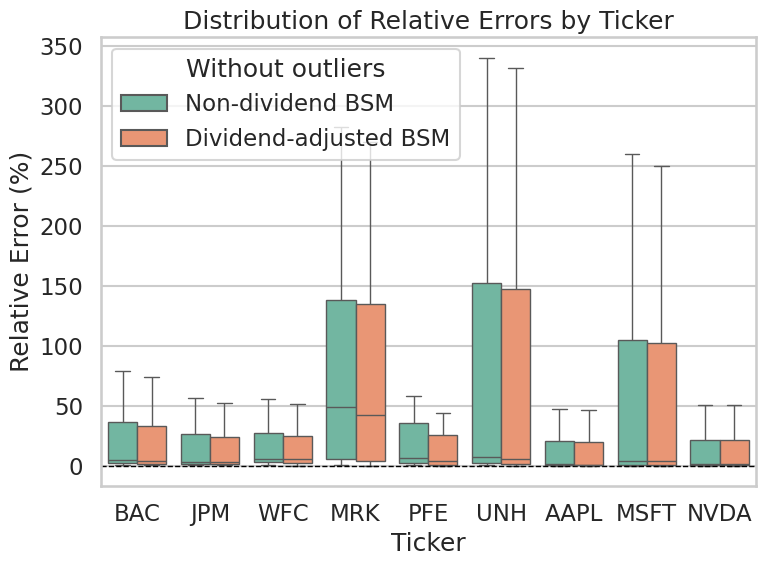

In [ ]:
# --- Visual 6: Boxplots of Relative Errors by Ticker ---
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Prepare dataset
df_box = df_flt.dropna(subset=["symbol", "relative_error_%", "relative_error_div_%"]).copy()
df_box["relative_error_%"] = pd.to_numeric(df_box["relative_error_%"], errors="coerce")
df_box["relative_error_div_%"] = pd.to_numeric(df_box["relative_error_div_%"], errors="coerce")
df_box = df_box.dropna(subset=["relative_error_%", "relative_error_div_%"])

# Melt into long form for seaborn
df_long = df_box.melt(
    id_vars=["symbol"],
    value_vars=["relative_error_%", "relative_error_div_%"],
    var_name="Model",
    value_name="Relative Error (%)"
)
df_long["Model"] = df_long["Model"].map({
    "relative_error_%": "Non-dividend BSM",
    "relative_error_div_%": "Dividend-adjusted BSM"
})

# Plot boxplots
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_long,
    x="symbol", y="Relative Error (%)", hue="Model",
    palette="Set2", showfliers= False
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Distribution of Relative Errors by Ticker")
plt.xlabel("Ticker")
plt.ylabel("Relative Error (%)")
plt.legend(title="Without outliers")
plt.tight_layout()
plt.show()

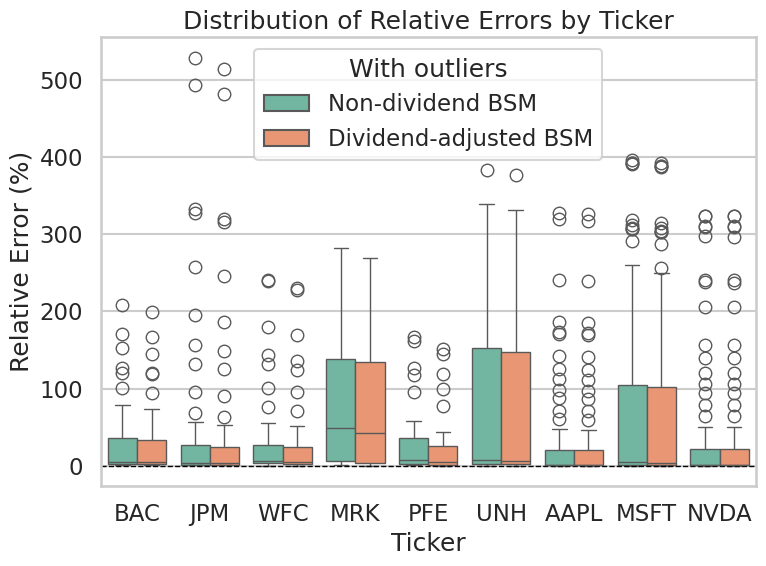

In [ ]:
# --- Visual 6: Boxplots of Relative Errors by Ticker ---
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Prepare dataset
df_box = df_flt.dropna(subset=["symbol", "relative_error_%", "relative_error_div_%"]).copy()
df_box["relative_error_%"] = pd.to_numeric(df_box["relative_error_%"], errors="coerce")
df_box["relative_error_div_%"] = pd.to_numeric(df_box["relative_error_div_%"], errors="coerce")
df_box = df_box.dropna(subset=["relative_error_%", "relative_error_div_%"])

# Melt into long form for seaborn
df_long = df_box.melt(
    id_vars=["symbol"],
    value_vars=["relative_error_%", "relative_error_div_%"],
    var_name="Model",
    value_name="Relative Error (%)"
)
df_long["Model"] = df_long["Model"].map({
    "relative_error_%": "Non-dividend BSM",
    "relative_error_div_%": "Dividend-adjusted BSM"
})

# Plot boxplots
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_long,
    x="symbol", y="Relative Error (%)", hue="Model",
    palette="Set2", showfliers= True
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Distribution of Relative Errors by Ticker")
plt.xlabel("Ticker")
plt.ylabel("Relative Error (%)")
plt.legend(title="With outliers")
plt.tight_layout()
plt.show()